<a href="https://colab.research.google.com/github/Yobrb/weather_prediction/blob/main/%D0%9F%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7_%D0%BF%D0%BE%D0%B3%D0%BE%D0%B4%D1%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import requests
import pandas as pd
import numpy as np
from datetime import date

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score,
    average_precision_score, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [12]:
#тянем данные
def fetch_weather(
    latitude: float = 16.07,
    longitude: float = 108.22,
    start: str = "2015-01-01",
    end: str = str(date.today()),
) -> pd.DataFrame:
    """
    Скачивает исторические почасовые данные с Open-Meteo
    и агрегирует их до суточного уровня.
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start,
        "end_date": end,
        "hourly": [
            "temperature_2m",
            "relative_humidity_2m",
            "precipitation",
            "surface_pressure",
            "windspeed_10m",
            "cloudcover",
        ],
        "timezone": "auto",
    }

    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    payload = r.json()

    hourly = payload["hourly"]
    df = pd.DataFrame(hourly)
    df["time"] = pd.to_datetime(df["time"])
    df = df.set_index("time")

    # Суточная агрегация
    daily = df.resample("D").agg(
        temp_mean=("temperature_2m", "mean"),
        temp_max=("temperature_2m", "max"),
        temp_min=("temperature_2m", "min"),
        temp_range=("temperature_2m", lambda x: x.max() - x.min()),
        humidity_mean=("relative_humidity_2m", "mean"),
        humidity_max=("relative_humidity_2m", "max"),
        precip_sum=("precipitation", "sum"),
        pressure_mean=("surface_pressure", "mean"),
        pressure_min=("surface_pressure", "min"),
        pressure_trend=("surface_pressure", lambda x: x.iloc[-1] - x.iloc[0]),  # изменение за сутки
        wind_mean=("windspeed_10m", "mean"),
        wind_max=("windspeed_10m", "max"),
        cloud_mean=("cloudcover", "mean"),
        cloud_max=("cloudcover", "max"),
    )
    print(f"{len(daily)} суток ({start} → {end})")
    return daily

In [13]:
def build_features(df: pd.DataFrame, rain_threshold: float = 1.0) -> pd.DataFrame:
    """
    Строит признаки и целевую переменную.
    target = 1, если осадки завтра > rain_threshold мм
    """
    fe = df.copy()

    # Лаги осадков (1-7 дней назад)
    for lag in range(1, 8):
        fe[f"precip_lag{lag}"] = fe["precip_sum"].shift(lag)

    # Скользящие средние осадков
    fe["precip_roll3"] = fe["precip_sum"].shift(1).rolling(3).mean()
    fe["precip_roll7"] = fe["precip_sum"].shift(1).rolling(7).mean()

    # Был ли дождь вчера / позавчера (бинарно)
    fe["rain_yesterday"] = (fe["precip_sum"].shift(1) > rain_threshold).astype(int)
    fe["rain_2d_ago"]    = (fe["precip_sum"].shift(2) > rain_threshold).astype(int)

    # Лаги давления
    for lag in range(1, 4):
        fe[f"pressure_lag{lag}"] = fe["pressure_mean"].shift(lag)

    # Изменение давления за 2 дня
    fe["pressure_delta2"] = fe["pressure_mean"].shift(1) - fe["pressure_mean"].shift(3)

    # Лаги влажности
    fe["humidity_lag1"] = fe["humidity_mean"].shift(1)
    fe["humidity_lag2"] = fe["humidity_mean"].shift(2)

    # Лаги облачности
    fe["cloud_lag1"] = fe["cloud_mean"].shift(1)

    # Календарные признаки
    fe["month"]      = fe.index.month
    fe["dayofyear"]  = fe.index.dayofyear
    fe["sin_doy"]    = np.sin(2 * np.pi * fe["dayofyear"] / 365)
    fe["cos_doy"]    = np.cos(2 * np.pi * fe["dayofyear"] / 365)

    # Целевая переменная: осадки завтра
    fe["target"] = (fe["precip_sum"].shift(-1) > rain_threshold).astype(int)

    # Убираем строки с NaN (из-за лагов и последнего дня без target)
    fe = fe.dropna()

    print(f"Доля дождливых дней: {fe['target'].mean():.1%}")
    return fe


In [14]:
def split_data(df: pd.DataFrame, test_years: int = 2):

    cutoff = df.index.max() - pd.DateOffset(years=test_years)
    train = df[df.index <= cutoff]
    test  = df[df.index  > cutoff]

    FEATURE_COLS = [c for c in df.columns if c != "target"]

    X_train, y_train = train[FEATURE_COLS], train["target"]
    X_test,  y_test  = test[FEATURE_COLS],  test["target"]

    return X_train, X_test, y_train, y_test, FEATURE_COLS

In [19]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 3.9 MB/s eta 0:00:00


In [20]:
import optuna
from xgboost import XGBClassifier

def objective(trial, X_train, y_train, tscv):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.5, 3.0),
        "random_state": 98,
        "n_jobs": -1,
        "eval_metric": "auc",
        "use_label_encoder": False,
    }

    cv_scores = []
    for tr_idx, val_idx in tscv.split(X_train):
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", XGBClassifier(**params))
        ])
        model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        prob = model.predict_proba(X_train.iloc[val_idx])[:, 1]
        cv_scores.append(roc_auc_score(y_train.iloc[val_idx], prob))

    return np.mean(cv_scores)


def train_models(X_train, y_train, n_optuna_trials=50):
    tscv = TimeSeriesSplit(n_splits=5)

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=98))
    study.optimize(lambda trial: objective(trial, X_train, y_train, tscv), n_trials=n_optuna_trials)

    best_xgb_params = study.best_params
    best_xgb_params.update({"random_state": 98, "n_jobs": -1, "eval_metric": "auc"})
    print(f"Лучший ROC-AUC на CV: {study.best_value:.4f}")

    models = {
        "LogisticRegression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, C=0.1)),
        ]),
        "XGBoost_Optuna": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", XGBClassifier(**best_xgb_params)),
        ]),
    }

    for name, model in models.items():
        cv_scores = []
        for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
            model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
            prob = model.predict_proba(X_train.iloc[val_idx])[:, 1]
            cv_scores.append(roc_auc_score(y_train.iloc[val_idx], prob))
        print(f"  {name}: ROC-AUC = {np.mean(cv_scores):.3f} ± {np.std(cv_scores):.3f}")

    for name, model in models.items():
        model.fit(X_train, y_train)

    return models

In [27]:
def evaluate(models: dict, X_test, y_test, feature_cols: list):

    fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5))
    if len(models) == 1:
        axes = [axes]

    results = {}
    for ax, (name, model) in zip(axes, models.items()):
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        roc   = roc_auc_score(y_test, y_prob)
        pr_ap = average_precision_score(y_test, y_prob)
        results[name] = {"ROC-AUC": roc, "Avg Precision": pr_ap}

        print(f"── {name} ──")
        print(f"   ROC-AUC:          {roc:.3f}")
        print(f"   Avg Precision:    {pr_ap:.3f}")
        print(classification_report(y_test, y_pred, target_names=["Нет дождя", "Дождь"]))

        ConfusionMatrixDisplay.from_predictions(
            y_test, y_pred,
            display_labels=["Нет дождя", "Дождь"],
            ax=ax, colorbar=False
        )
        ax.set_title(f"{name}\nROC-AUC={roc:.3f}")

    plt.tight_layout()
    plt.show()

    # Feature importance для GBM
    if "XGBoost_Optuna" in models:
        clf = models["XGBoost_Optuna"].named_steps["clf"]
        imp = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=True)
        top20 = imp.tail(20)

        fig, ax = plt.subplots(figsize=(8, 6))
        top20.plot.barh(ax=ax, color="#3B82F6")
        ax.set_title("Feature Importance (XGBoost_Optuna) — Top 20")
        ax.set_xlabel("Importance")
        plt.tight_layout()
        plt.show()

    return results

In [28]:
def predict_tomorrow(model, df_features: pd.DataFrame, feature_cols: list):
    """
    Берёт последнюю доступную строку (сегодняшние данные)
    и выдаёт вероятность дождя завтра.
    """
    last_row = df_features[feature_cols].iloc[[-1]]
    prob = model.predict_proba(last_row)[0, 1]
    label = "Дождь" if prob >= 0.6 else "Дождя нет"
    print(f"\n Прогноз на завтра ({df_features.index[-1].date() + pd.Timedelta(days=1)}):")
    print(f"   Вероятность осадков: {prob:.1%}  →  {label}")
    return prob

[I 2026-06-20 16:43:37,973] A new study created in memory with name: no-name-fec5fcb1-87fd-4b47-99ba-4b10e52ce798


4189 суток (2015-01-01 → 2026-06-20)
Доля дождливых дней: 53.8%


[I 2026-06-20 16:43:50,134] Trial 0 finished with value: 0.832219251585618 and parameters: {'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.027857632857946426, 'subsample': 0.9122331701910686, 'colsample_bytree': 0.7991497111498473, 'min_child_weight': 3, 'reg_alpha': 3.140766897977475e-05, 'reg_lambda': 3.56274808120251e-05, 'scale_pos_weight': 1.3438139455831912}. Best is trial 0 with value: 0.832219251585618.
[I 2026-06-20 16:43:51,143] Trial 1 finished with value: 0.8501519512867178 and parameters: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.0401774321228521, 'subsample': 0.9733058648506171, 'colsample_bytree': 0.7167969062251616, 'min_child_weight': 17, 'reg_alpha': 7.99764305070708, 'reg_lambda': 5.4634596078405004e-05, 'scale_pos_weight': 2.2427235630872917}. Best is trial 1 with value: 0.8501519512867178.
[I 2026-06-20 16:43:56,769] Trial 2 finished with value: 0.8161366356541674 and parameters: {'n_estimators': 1000, 'max_depth': 5, 'learning_rate': 0.1032

Лучший ROC-AUC на CV: 0.8536
  LogisticRegression: ROC-AUC = 0.834 ± 0.022
  XGBoost_Optuna: ROC-AUC = 0.854 ± 0.021
── LogisticRegression ──
   ROC-AUC:          0.823
   Avg Precision:    0.850
              precision    recall  f1-score   support

   Нет дождя       0.69      0.77      0.73       328
       Дождь       0.79      0.72      0.75       402

    accuracy                           0.74       730
   macro avg       0.74      0.74      0.74       730
weighted avg       0.75      0.74      0.74       730

── XGBoost_Optuna ──
   ROC-AUC:          0.861
   Avg Precision:    0.887
              precision    recall  f1-score   support

   Нет дождя       0.85      0.49      0.62       328
       Дождь       0.69      0.93      0.79       402

    accuracy                           0.73       730
   macro avg       0.77      0.71      0.71       730
weighted avg       0.76      0.73      0.71       730



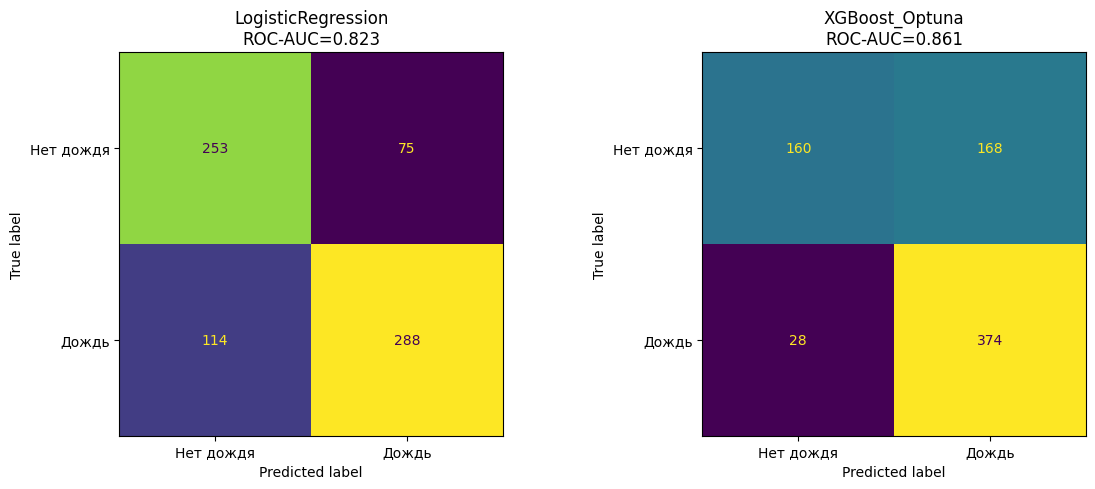

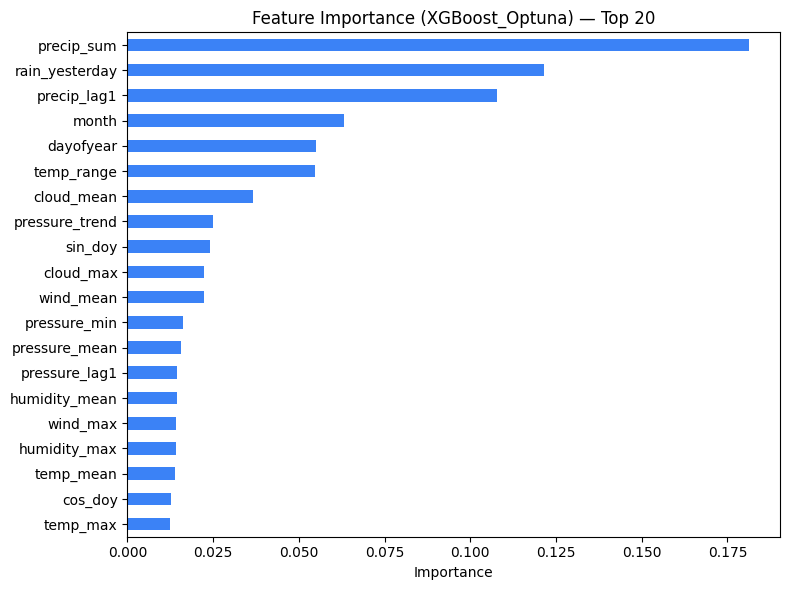


 Прогноз на завтра (2026-06-21):
   Вероятность осадков: 27.6%  →  Дождя нет


np.float32(0.27575645)

In [29]:
df_raw = fetch_weather()

df_feat = build_features(df_raw)

X_train, X_test, y_train, y_test, feat_cols = split_data(df_feat, test_years=2)

models = train_models(X_train, y_train)

results = evaluate(models, X_test, y_test, feat_cols)

best_model = models["XGBoost_Optuna"]
predict_tomorrow(best_model, df_feat, feat_cols)